1. Imports

In [1]:
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from src.models.train import load_data, build_preprocessor
from src.models.explain import (
    plot_shap_summary, plot_shap_beeswarm,
    plot_waterfall_examples, error_analysis
)

2. Rebuild data and model

In [2]:
X, y_multi = load_data()
y_binary = (y_multi == 2).astype(int)

X_temp, X_test_b, y_temp, y_test_b = train_test_split(
    X, y_binary, test_size=0.15, stratify=y_binary, random_state=42
)
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42
)

# Best params from Optuna
clf_final = LGBMClassifier(
    n_estimators=657, learning_rate=0.09961458744367316,
    num_leaves=146, max_depth=4, min_child_samples=48,
    subsample=0.9454531813600874, colsample_bytree=0.6787320932541822,
    reg_alpha=7.672758684666764e-08, reg_lambda=5.935259650996604e-07,
    scale_pos_weight=1.5262860107942606,
    random_state=42, n_jobs=-1, verbose=-1,
)

pipe_final = ImbPipeline([
    ("pre", build_preprocessor()),
    ("smote", SMOTE(random_state=42)),
    ("clf", clf_final),
])
pipe_final.fit(X_train_b, y_train_b)

BEST_THRESHOLD = 0.35
y_proba_test = pipe_final.predict_proba(X_test_b)[:, 1]
print("Model ready.")

Loaded: C:\Users\dell\food-outbreak-severity-ml\data\processed\outbreaks_featured.csv  →  X(18745, 13)  y(18745,)
Class distribution:
Severity_code
0    9823
1    6128
2    2794



  File "C:\Users\dell\food-outbreak-severity-ml\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Model ready.


3. SHAP Summary Plot

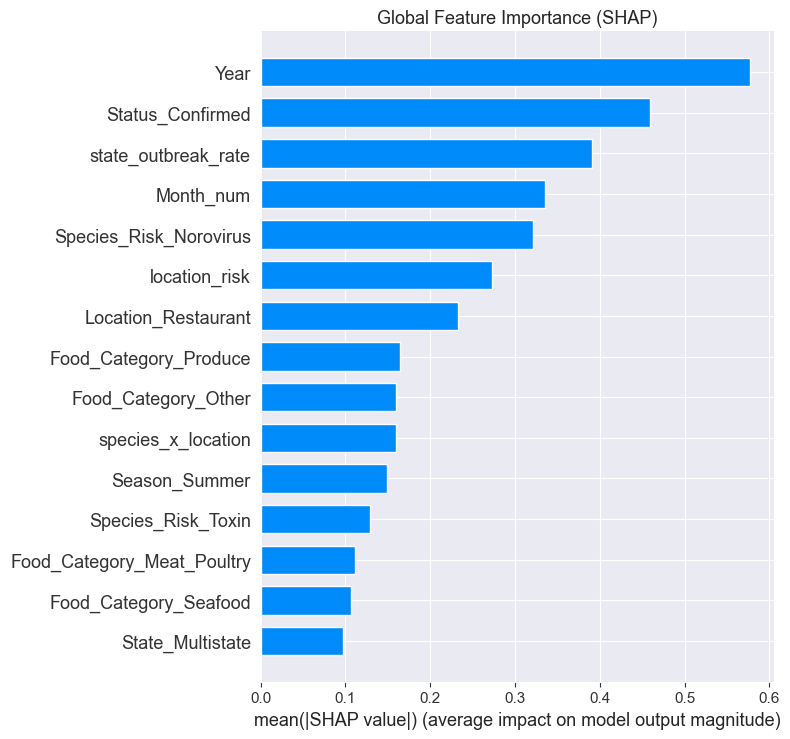

Saved -> C:\Users\dell\food-outbreak-severity-ml\reports\figures\shap_summary.png


In [6]:
import importlib
import src.models.explain as exp
importlib.reload(exp)
from src.models.explain import plot_shap_summary, plot_shap_beeswarm, plot_waterfall_examples, error_analysis

shap_values, X_transformed = plot_shap_summary(pipe_final, X_val_b, max_samples=500)

4. Beeswarm plot

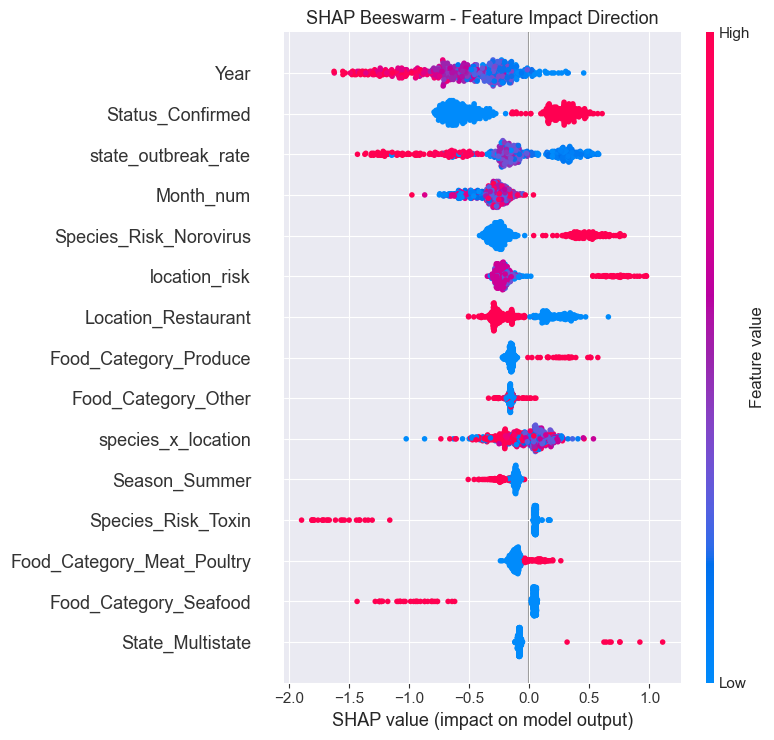

Saved -> C:\Users\dell\food-outbreak-severity-ml\reports\figures\shap_beeswarm.png


In [7]:
plot_shap_beeswarm(pipe_final, X_val_b, max_samples=500)

5. Waterfall examples

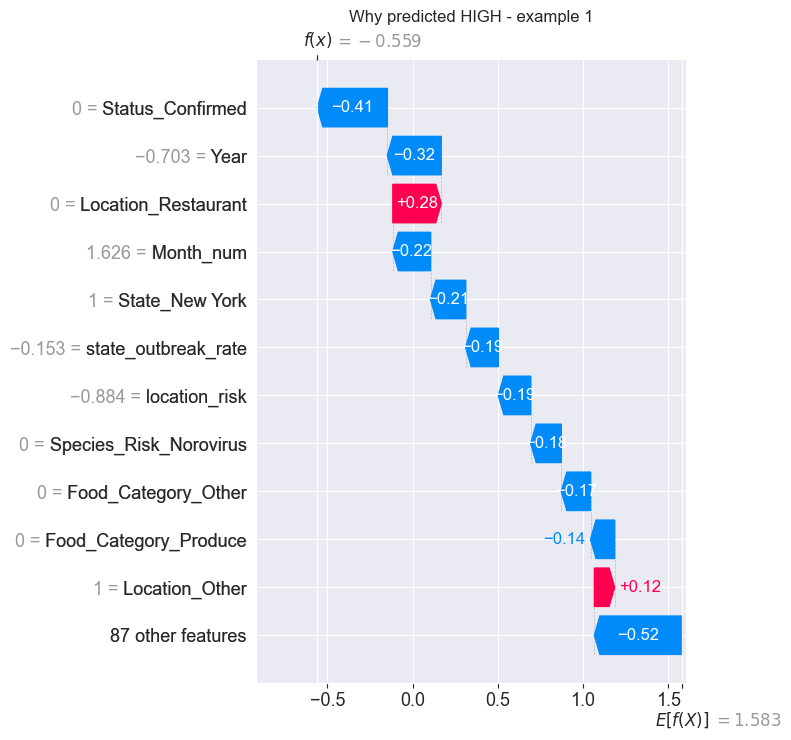

Saved -> C:\Users\dell\food-outbreak-severity-ml\reports\figures\shap_waterfall_1.png


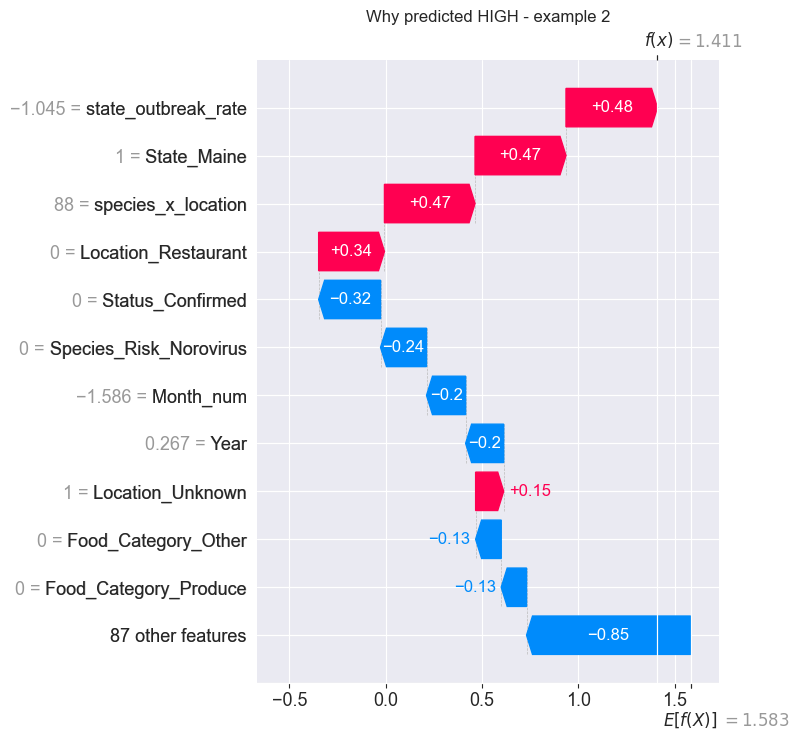

Saved -> C:\Users\dell\food-outbreak-severity-ml\reports\figures\shap_waterfall_2.png


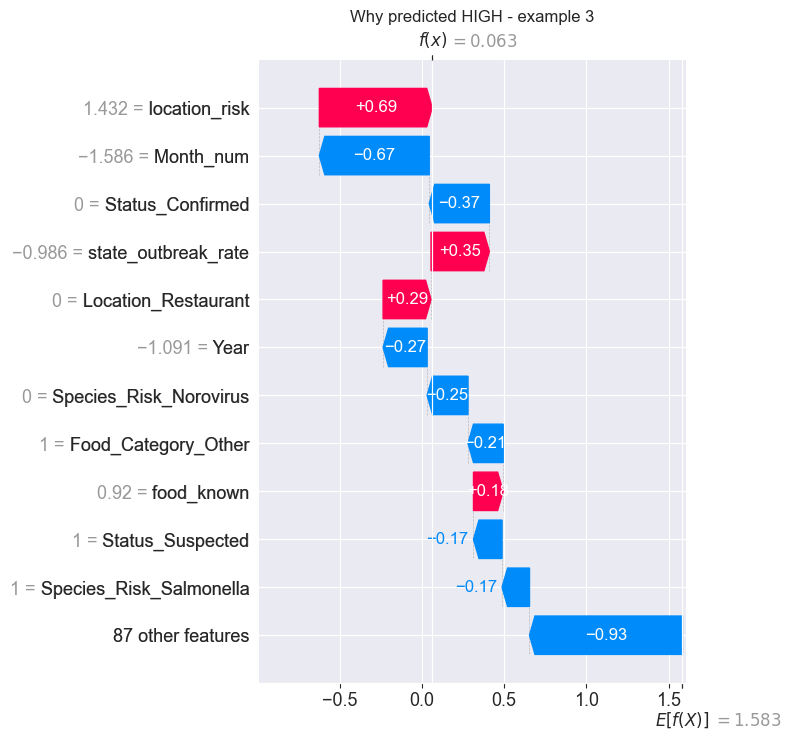

Saved -> C:\Users\dell\food-outbreak-severity-ml\reports\figures\shap_waterfall_3.png


In [8]:
plot_waterfall_examples(pipe_final, X_val_b, y_val_b,
                        pipe_final.predict_proba(X_val_b)[:,1],
                        threshold=0.35, n=3)

6. Error Analysis

In [9]:
fn, fp = error_analysis(X_val_b, y_val_b,
                        pipe_final.predict_proba(X_val_b)[:,1],
                        threshold=0.35)

False Negatives (missed High): 189
False Positives (false alarms): 336

--- Missed High outbreaks (FN) - Location breakdown ---
Location
Restaurant                               103
Unknown                                   24
Private Home/Residence                    21
Catering Service                          15
Banquet Facility                           8
Other                                      5
School/College/University                  4
Nursing Home/Assisted Living Facility      3
Name: count, dtype: int64

--- Missed High outbreaks (FN) - Species_Risk breakdown ---
Species_Risk
Norovirus      70
Unknown        46
Medium_Risk    31
Salmonella     22
High_Risk      11
Other           7
Toxin           2
Name: count, dtype: int64

--- False alarms (FP) - Location breakdown ---
Location
Restaurant                   96
Catering Service             75
Unknown                      65
Private Home/Residence       21
Banquet Facility             17
Other                        15
Sc

7. Full metrics summary

In [10]:
from sklearn.metrics import accuracy_score

y_pred_test = (pipe_final.predict_proba(X_test_b)[:,1] >= 0.35).astype(int)

print("=== FINAL MODEL METRICS ===")
print(f"Accuracy:      {accuracy_score(y_test_b, y_pred_test)*100:.1f}%")
print(f"ROC-AUC:       {roc_auc_score(y_test_b, pipe_final.predict_proba(X_test_b)[:,1])*100:.1f}%")
print(f"Macro F1:      {f1_score(y_test_b, y_pred_test, average='macro')*100:.1f}%")
print(f"High Recall:   {f1_score(y_test_b, y_pred_test, pos_label=1, average='binary')*100:.1f}%")

=== FINAL MODEL METRICS ===
Accuracy:      82.3%
ROC-AUC:       82.7%
Macro F1:      69.6%
High Recall:   50.1%
